# Preparación y calidad de datos

Se realizará una limpieza y control de la calidad de los datos de mercadotecnica, ventas y catálogo con el fin de garantizar una confiabilidad en el análisis.

## importación de librerías y carga de datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders_raw = pd.read_csv(r'../data/rappiplus_orders_raw.csv')
catalog_raw = pd.read_csv(r'../data/rappiplus_catalog.csv')
marketing_raw = pd.read_csv(r'../data/rappiplus_marketing_spend.csv')

## Exploración de datasets

Se identificarán los deffectos y ajustes a realizar para cada dataset, para posteriormente limpiar y garantizar la confiabilidad del análisis.

### Dataset de ordenes

In [3]:
print(f'Cantidad de registros: {orders_raw.shape[0]}')

Cantidad de registros: 25100


In [4]:
orders_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  str    
 1   id_usuario          25100 non-null  str    
 2   fecha_hora_pedido   25100 non-null  str    
 3   pais                24800 non-null  str    
 4   dispositivo         25080 non-null  str    
 5   fuente_referencia   25070 non-null  str    
 6   nombre_producto     25070 non-null  str    
 7   categoria_producto  25020 non-null  str    
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), str(8)
memory usage: 2.3 MB


In [5]:
orders_raw.describe().round(3)

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000,25050.000,25050.000,25100.000
mean,7.093,259.306,4.501,2072.680
std,296.277,138.726,5.223,98949.950
min,-2.000,20.030,0.000,-492.650
25%,1.000,138.378,0.000,180.508
50%,2.000,258.715,0.000,341.750
75%,2.000,380.332,10.000,518.580
max,20000.000,499.960,15.000,8840200.000


In [6]:
print('Registros con valor negativo en columna cantidad:', orders_raw[orders_raw['cantidad'] < 0].shape[0])
print()
print('Registros con valor negativo en monto total:', orders_raw[orders_raw['monto_total'] < 0].shape[0])
print()
print('Registros duplicados:', orders_raw.duplicated().sum())

Registros con valor negativo en columna cantidad: 4

Registros con valor negativo en monto total: 4

Registros duplicados: 100


In [7]:
print('Conteo de valores nulso por columna:')
orders_raw.isna().sum()

Conteo de valores nulso por columna:


id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

In [8]:
print('Porcentaje de valores nulos por columna:')
orders_raw.isna().sum() / len(orders_raw) * 100

Porcentaje de valores nulos por columna:


id_pedido             0.000000
id_usuario            0.000000
fecha_hora_pedido     0.000000
pais                  1.195219
dispositivo           0.079681
fuente_referencia     0.119522
nombre_producto       0.119522
categoria_producto    0.318725
cantidad              0.199203
precio_unitario       0.199203
monto_descuento       0.199203
monto_total           0.000000
dtype: float64

Defectos del dataset:
- Cambiar formato de dato **fecha_hora_pedido a tipo fecha**
- Hay **100 filas** con id_pedido **duplicado**, se deben eliminar
- **Cantidad y monto_total** tienen **4 valores negativos**
- Columna país tiene **300 valores vacíos** (1.19%)
- Dispositivo tiene **20 valores vacíos** (0.08%)
- Fuente de referencia y nombre del producto tienen **30 valores vacíos c/u** (0.12%)
- Categoría de producto tiene **80 valores vacíos** (0.32%)
- Cantidad, precio unitario y monto de descuento tienen **50 valores vacíos c/u** (0.20%)
- Cantidad tiene 20,000 como valor máximo mientras que los 3 cuartiles previos se mantienen hasta 2
- Los paises tiene formato minuscula completa y titulo, debemos unifircarlos a titulo

### Dataset de Marketing

In [9]:
print(f'Cantidad de registros: {marketing_raw.shape[0]}')

Cantidad de registros: 1620


In [10]:
marketing_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   str    
 1   pais        1620 non-null   str    
 2   id_campaña  1620 non-null   str    
 3   canal       1519 non-null   str    
 4   gasto       1620 non-null   float64
dtypes: float64(1), str(4)
memory usage: 63.4 KB


In [11]:
marketing_raw.describe().round(3)

,gasto
count,1620.000
mean,1772.743
std,734.433
min,501.110
25%,1128.030
50%,1782.425
75%,2420.685
max,2999.360


In [12]:
marketing_raw[marketing_raw['canal'].isna()]

,fecha,pais,id_campaña,canal,gasto
98,2025-01-11,Argentina,social_Argentina,NaN,849.70
99,2025-01-12,Mexico,organic_Mexico,NaN,2033.56
100,2025-01-12,Mexico,paid_search_Mexico,NaN,1260.65
101,2025-01-12,Mexico,social_Mexico,NaN,1660.90
102,2025-01-12,Colombia,organic_Colombia,NaN,1819.27
...,...,...,...,...,...
194,2025-01-22,Colombia,social_Colombia,NaN,772.46
195,2025-01-22,Argentina,organic_Argentina,NaN,1562.61
196,2025-01-22,Argentina,paid_search_Argentina,NaN,644.34
197,2025-01-22,Argentina,social_Argentina,NaN,2544.66


In [13]:
print('Valores únicos en columna id_campaña:', 
      marketing_raw['id_campaña'].unique())

Valores únicos en columna id_campaña: <StringArray>
[       'organic_Mexico',    'paid_search_Mexico',         'social_Mexico',
      'organic_Colombia',  'paid_search_Colombia',       'social_Colombia',
     'organic_Argentina', 'paid_search_Argentina',      'social_Argentina']
Length: 9, dtype: str


- Es necesario corregir el formato del tipo de dato de la columna fecha a **tipo fecha**
- Tenemos 101 registros vacíos en la columna **canal**, sin embargo, los id_campaña llevan como clave el país y el canal por el que se realizó la campaña, por lo que podemos extraer y rellenar el valor de los canales gracias al identificador

### Dataset de Catálogo

In [14]:
print(f'Cantidad de registros: {catalog_raw.shape[0]}')

Cantidad de registros: 7


In [15]:
catalog_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      str    
 1   categoria_producto  7 non-null      str    
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      str    
dtypes: float64(1), str(3)
memory usage: 356.0 bytes


In [16]:
catalog_raw.nunique()

nombre_producto       7
categoria_producto    3
costo_unitario        7
proveedor             7
dtype: int64

Dataset de catálogo se ve correcto, no hay correcciones por realizar

## Limpieza de datos y cálculo estadístico

Previo a cualquier eliminación de datos faltantes, se realizarán los ajuste, correcciones y agregaciones correspondientes con el fin de garantizar una mayor calidad en datos, de esta forma unicamente los registros vacios si resultan no ser demasiados, podríamos proceder con la eliminación de estos sin perjudicar la confiabilidad de los datos.

### Creación de copias de dataset

In [17]:
orders_clean = orders_raw.copy()
catalog_clean = catalog_raw.copy()
marketing_clean = marketing_raw.copy()

### Dataset de **Ordenes**

#### Cambio de formato a columnas fecha (datetime)

Con fines de practicidad, se aplicará igual el cambio de formato a tipo fecha en la columna fecha de los datasets *orders* y *marketing*

In [18]:
# Función de automatización para convertir columnas de fecha a tipo datetime
def date_format(df, date_column, format= None):
    df[date_column] = pd.to_datetime(df[date_column], format=format, errors='coerce')
    
    return df

In [19]:
# Ejecución de función a columnas fehca de los dataset de orden y de marketing
orders_clean = date_format(orders_clean, 'fecha_hora_pedido')
marketing_clean = date_format(marketing_clean, 'fecha')

In [20]:
print(f'Tipo de dato de columna "fecha_hora_pedido": {orders_clean['fecha_hora_pedido'].dtype}')

Tipo de dato de columna "fecha_hora_pedido": datetime64[us]


#### Rellenado de columnas país cómo desconocido y capitalización de primera letra

Para no perder los datos, pero con el propósito de no inflar artificalmente los datos de esta columna, se reemplazará por la categoría *desconocido* para tener presente la importancia de la magnitud de estos fallos al momento de registrar los datos.

De igual manera se pondrá en formato título (primera letra en mayuscula), para mayor uniformidad de datos

In [21]:
# Función para rellenar valores nulos con texto 'desconocido'
def fill_na_desc(df, column, fill_value='desconocido'):
    df[column] = df[column].fillna(fill_value)
    df[column] = df[column].str.title() # Capitaliza la primera letra de cada palabra
    return df

In [22]:
# ejecución de la función en columna país
orders_clean = fill_na_desc(orders_clean, 'pais')

In [23]:
# Comprobación de que se aplicó la función correctamente
print('Conteo de valores por país y comprobación de nueva categoría "desconocido":\n', 
      orders_clean['pais'].value_counts())

Conteo de valores por país y comprobación de nueva categoría "desconocido":
 pais
Mexico         8367
Colombia       8343
Argentina      8090
Desconocido     300
Name: count, dtype: int64


#### Eliminación de registros duplicados por id_pedido, mantiendo el primero de cada duplicado

In [24]:
orders_clean = orders_clean.drop_duplicates(subset=['id_pedido'], keep='first')

In [25]:
print(f'Cantidad de id de pedido duplicados: {orders_clean['id_pedido'].duplicated().sum()}')

Cantidad de id de pedido duplicados: 0


#### Imputación de dispositivos aprovechando la probabilidad

In [26]:
# 1. Probabilidades reales de cada categoría para aparecer
probabilidades = orders_clean['dispositivo'].value_counts(normalize=True)

print('Probabilidades de que cada categoría de dispositivo aparezca en los datos:')
probabilidades

Probabilidades de que cada categoría de dispositivo aparezca en los datos:


dispositivo
desktop    0.508847
mobile     0.491153
Name: proportion, dtype: float64

In [27]:
# Obtención de los índices de los 20 registros nulos
indices_nulos = orders_clean[orders_clean['dispositivo'].isna()].index

# Generación de valores aleatorios para cada nulo respetando probabilidades reales
valores_imputados = np.random.choice(
    a= probabilidades.index,
    size= len(indices_nulos),
    p= probabilidades.values
)

orders_clean.loc[indices_nulos, 'dispositivo'] = valores_imputados

In [28]:
# Comprobación de que no hay más valores nulos en dispositivo
print('Valores nulos en columna "dispositivo":',
      orders_clean['dispositivo'].isna().sum())

print('\nConteo de valores por categoría de dispositivo:')
display(orders_clean['dispositivo'].value_counts())

Valores nulos en columna "dispositivo": 0

Conteo de valores por categoría de dispositivo:


dispositivo
desktop    12725
mobile     12275
Name: count, dtype: int64

#### Eliminación de filas con registros vacíos y rellenados en columnas *referencia, nombre de producto y categoría*

In [29]:
orders_raw[orders_raw['nombre_producto'].isna()].head(2)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
44,order_44,user_2899,2025-02-22,Colombia,desktop,NaN,NaN,NaN,1.0,318.38,5.0,313.38
45,order_45,user_6196,2025-02-10,Mexico,mobile,NaN,NaN,NaN,2.0,354.06,10.0,698.12


In [30]:
# Muestra todas las combinaciones posibles de Nulos (True) y No Nulos (False)
columnas_interes = ['fuente_referencia', 'nombre_producto', 'categoria_producto']

print('Conteo de combincaciones de valores nulos y no nulos en columnas fuente de \nreferencia, nombre y categoría de producto:')

orders_clean[columnas_interes].isna().value_counts()

Conteo de combincaciones de valores nulos y no nulos en columnas fuente de 
referencia, nombre y categoría de producto:


fuente_referencia  nombre_producto  categoria_producto
False              False            False                 24920
                                    True                     50
True               True             True                     30
Name: count, dtype: int64

In [31]:
# Filtrar filas donde falta 'categoria_producto' PERO SÍ existe 'nombre_producto'
patron_categoria = orders_clean[
    orders_clean['categoria_producto'].isna() & orders_clean['nombre_producto'].notna()
]

# Mostrar esas filas
patron_categoria[['nombre_producto', 'categoria_producto', 'monto_total']].head(2)

,nombre_producto,categoria_producto,monto_total
74,Sneakers-Urban-42,NaN,595.85
75,Sneakers-Urban-42,NaN,458.15


El código ejecuta una estrategia de recuperación por inferencia lógica en tres pasos:

1. Construcción del diccionario de referencia (`mapa_categorias`):
Filtra los datos válidos existentes y elimina duplicados para crear un catálogo {nombre_producto: categoria_producto}. Esto establece la relación "verdadera" entre cada producto y su categoría.

2. Imputación por mapeo (``.map() + .fillna()``):
Para las 50 filas que tenían producto pero carecían de categoría, el código consulta el catálogo y asigna automáticamente la categoría correspondiente a partir del nombre del producto.

3. Depuración de registros irrecuperables (``.dropna()``):
Elimina únicamente las 30 filas donde nombre_producto es nulo. Al estar vacías también en categoría y fuente de referencia, su eliminación limpia el 100% de los vacíos restantes en estas tres columnas.

In [32]:
def limpiar_cat_producto(df):
    """
    Rellena las categorías de productos vacías realizando un 
    mapeo de productos existentes y elimina los registros sin nombre de producto
    """
    # Diccionario de mapeo (Producto -> Categoría)
    categoric_map = (df.dropna(subset=['categoria_producto'])
                     .drop_duplicates('nombre_producto')
                     .set_index('nombre_producto')['categoria_producto']
                     .to_dict()
                     )

    # Imputación de categorías faltantes usando nombre del producto
    df['categoria_producto'] = df['categoria_producto'].fillna(
        df['nombre_producto'].map(categoric_map)
    )

    # Eliminación de filas inviables (no hay producto)
    df = df.dropna(subset=['nombre_producto'])

    return df


In [33]:
orders_clean = limpiar_cat_producto(orders_clean)

orders_clean.info()

<class 'pandas.DataFrame'>
Index: 24970 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24970 non-null  str           
 1   id_usuario          24970 non-null  str           
 2   fecha_hora_pedido   24970 non-null  datetime64[us]
 3   pais                24970 non-null  str           
 4   dispositivo         24970 non-null  str           
 5   fuente_referencia   24970 non-null  str           
 6   nombre_producto     24970 non-null  str           
 7   categoria_producto  24970 non-null  str           
 8   cantidad            24920 non-null  float64       
 9   precio_unitario     24920 non-null  float64       
 10  monto_descuento     24920 non-null  float64       
 11  monto_total         24970 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(7)
memory usage: 2.5 MB


#### Corrección de valores negativos

In [ ]:
# Filtrado de registros con valores negativos en cantidad o monto_total
negativos = orders_clean[(orders_clean['cantidad'] < 0) | (orders_clean['monto_total'] < 0)]
negativos[['id_pedido', 'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']]

,id_pedido,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,-2.0,101.31,10.0,-192.62
267,order_267,-1.0,43.50,5.0,-38.50
268,order_268,-1.0,497.65,5.0,-492.65
269,order_269,-1.0,423.53,0.0,-423.53


In [ ]:
# Corrección de valores negativos mediante valor absoluto
orders_clean['cantidad'] = orders_clean['cantidad'].abs()
orders_clean['monto_total'] = orders_clean['monto_total'].abs()

In [ ]:
# Comprobación de corrección de valores negativos
orders_clean[['cantidad','monto_total']].describe().round(3)

,cantidad,monto_total
count,24920.000,24970.000
mean,7.122,2081.598
std,297.049,99207.125
min,1.000,5.240
25%,1.000,180.758
50%,2.000,341.925
75%,2.000,518.438
max,20000.000,8840200.000


#### Valores nulos en columnas numéricas

In [ ]:
# Muestra de combinaciones posibles de nulos (True) y  no nulos (False) en las columnas numéricas
cols_numericas = ['cantidad', 'precio_unitario', 'monto_descuento']

print('Posibles combinaciones de valores nulos y no nulos en columnas numéricas:')
orders_clean[cols_numericas].isna().value_counts()

Posibles combinaciones de valores nulos y no nulos en columnas numéricas:


cantidad  precio_unitario  monto_descuento
False     False            False              24920
True      True             True                  50
Name: count, dtype: int64

Realizando un análisis de las posibles comnbinaciones de nulos y no nulos en las columnas numéricas, se encontró que hay 50 filas con las 3 columnas numéricas en valores nulos, provocando que estos resgistros sean irrescatables o útiles para el análisis.

In [ ]:
# Verificar cuántos precios unitarios distintos existen por producto en los datos válidos
precios_por_producto = (
    orders_clean.dropna(subset=['precio_unitario'])
    .groupby('nombre_producto')['precio_unitario']
    .nunique()
)

print(f'Cantidad de precios unitarios distintos por producto:\n{precios_por_producto}')

Cantidad de precios unitarios distintos por producto:
nombre_producto
Blender-XL-Red          4012
Jacket-Winter-M         3993
Laptop-Gaming-16GB      2705
Phone-Pro-128GB         2659
Sneakers-Urban-42       3949
Tablet-Standard-64GB    2696
Vacuum-Pro-Black        4017
Name: precio_unitario, dtype: int64


Previo a eliminarlo, buscamos cuántos precios unitaios únicos tenemos por producto, resultando en una variabilidad de precios unitarios por producto demasiado elevados, indicando que no hay manera precisa de extraer montos unitarios sin recurrir a la manipulación de los datos, perjudicando la calidad de estos e inflando o reduciendo la información para ciertos productos o categorías

In [ ]:
# Eliminar las 50 filas con nulos numéricos simultáneos (irrecuperables)
orders_clean = orders_clean.dropna(subset=['cantidad'])

In [ ]:
# Verificación final de nulos en todo el dataset
print("Conteo de nulos por columna:")
print(orders_clean.isna().sum())

Conteo de nulos por columna:
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64


#### Revisión de outliers en columnas numéricas

En las columnas numéricas tenemos *cantidad*, *precio unitario*, *monto de descuento* y *monto total*.

Recordando que los precios unitarios tienen una variabilidad elevada en cada articulo, podemos comprender que es parte del sistema de venta de RappiPlus tener esta cantidad de precios por artículo, sin embargo, como se señaló en la exploración, tenemos registros de compra de hasta 20,000 unidades, algo ilógico para un negocio de retail.

Estas cantidades sin sentido en esta columna deben tratarse con cuidado, winzorizando los valores dentro de un rango de confiabilidad para evitar que permanezcan infladas las ventas, pero tampoco alterar sin sentido la información cuantitativa.

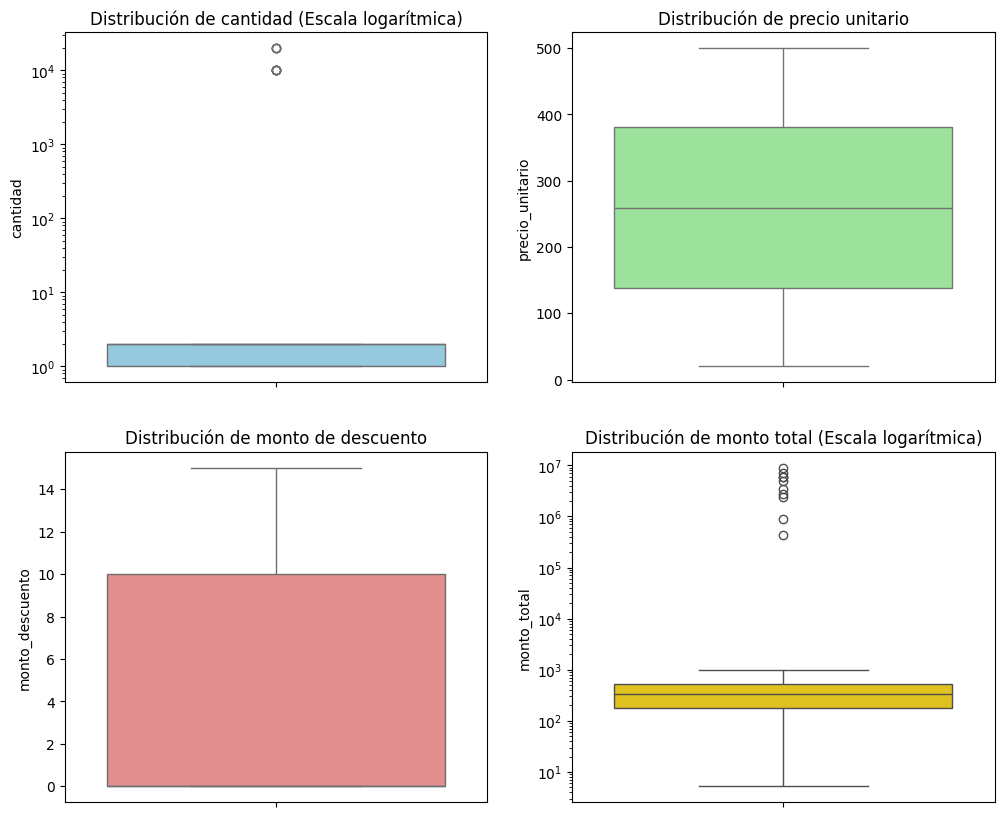

In [ ]:
# Boxplots para visualizar estado actual de columnas numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(y= orders_clean['cantidad'], ax= axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribución de cantidad (Escala logarítmica)')
axes[0, 0].set_yscale('log')

sns.boxplot(y= orders_clean['precio_unitario'], ax= axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Distribución de precio unitario')

sns.boxplot(y= orders_clean['monto_descuento'], ax= axes[1, 0], color= 'lightcoral')
axes[1, 0].set_title('Distribución de monto de descuento')

sns.boxplot(y= orders_clean['monto_total'], ax= axes[1, 1], color= 'gold')
axes[1, 1].set_title('Distribución de monto total (Escala logarítmica)')
axes[1, 1].set_yscale('log')

plt.show()


Se aprecia claramente presencia de outliers en las columnas de cantidad y de monto total.

Esto tiene lógica debido a que si tenemos registros con cantidades exageradamente altos, el monto total naturalmente se va a disparar igual de exagerado. Para evitar distroción en las columnas, se procederá a winzorizar los valores superiores al percentil 99, menteniendo una integridad en los datos, pero sin tener valores exagerados que inflen a los mismos

In [ ]:
p99 = orders_clean['cantidad'].quantile(0.99)

print(f'Cantidad de articulos por venta según el percentil 99: {p99}')

Cantidad de articulos por venta según el percentil 99: 2.0


In [ ]:
# Aplicación del percentil 99 a la columna cantidad para no afectar al comportamiento de compra
orders_clean['cantidad'] = np.clip(orders_clean['cantidad'], a_min= None, a_max= p99)

# Recalculo del monto total para sanear la variable dependiente
orders_clean['monto_total'] = (orders_clean['cantidad'] * orders_clean['precio_unitario']) - orders_clean['monto_descuento']

In [ ]:
orders_clean[['cantidad', 'monto_total']].describe().round(3)

,cantidad,monto_total
count,24920.000,24920.000
mean,1.505,385.910
std,0.500,255.669
min,1.000,5.240
25%,1.000,180.625
50%,2.000,341.560
75%,2.000,517.745
max,2.000,999.880


Unicamente se winzorizó la columna *cantidad* para posteriormente ejecutar el cálculo lógico de monto total (precio unitario * cantidad)

### Dataset **Marketing**

#### Ajuste de formato fecha

In [ ]:
# Aplicación de la función de conversión de fecha al dataset marketing
marketing_clean = date_format(marketing_clean, 'fecha')

print(f'Tipo de dato de la columna fecha: {marketing_clean['fecha'].dtypes}')

Tipo de dato de la columna fecha: datetime64[us]


#### Corrección de valores nulos en la columna canal

Se identificaron **101 registros faltantes** en la columna *canal* dentro del dataset *marketing_clean*.

Se encontró que la variable *id_campaña* sigue una estructura estandarizada compuesta por el formato *[canal]_[pais]*. 

Dado que el canal de marketing está explícitamente contenido en la clave única de la campaña, es posible **reconstruir el 100% de los datos faltantes de forma lógica y determinista** sin necesidad de imputaciones probabilísticas ni eliminación de registros.

In [ ]:
# Crear diccionario de mapeo id_campaña -> canal a partir de datos válidos
mapa_canales = (
    marketing_raw.dropna(subset=['canal'])
    .drop_duplicates('id_campaña')
    .set_index('id_campaña')['canal']
    .to_dict()
)

In [ ]:
# Imputar los 101 valores nulos en 'canal'
marketing_clean['canal'] = marketing_clean['canal'].fillna(
    marketing_clean['id_campaña'].map(mapa_canales)
)

In [ ]:
# Extraer el canal desde id_campaña
canal_esperado = marketing_clean['id_campaña'].str.rsplit('_', n=1).str[0]

# Filtrar filas donde el canal actual no coincida con el esperado
inconsistencias = marketing_clean[marketing_clean['canal'] != canal_esperado]

#  Mostrar resumen de validación
print(f"Total de registros evaluados: {len(marketing_clean)}")
print(f"Inconsistencias detectadas: {len(inconsistencias)}")

if len(inconsistencias) > 0:
    print("\n⚠️ ¡Atención! Se encontraron las siguientes discrepancias:")
    display(inconsistencias[['id_campaña', 'canal']])
else:
    print("\n✅ ¡Verificación exitosa! El 100% de los canales coinciden perfectamente con su id_campaña.")

Total de registros evaluados: 1620
Inconsistencias detectadas: 0

✅ ¡Verificación exitosa! El 100% de los canales coinciden perfectamente con su id_campaña.


## Creación de datasets limpios para análisis

In [ ]:
orders_clean.to_csv(r'../data/rappiplus_orders_clean.csv', index = False)
marketing_clean.to_csv(r'../data/rappiplus_marketing_clean.csv', index = False)
catalog_clean.to_csv(r'../data/rappiplus_catalog_clean.csv', index = False)

In [36]:
orders_clean.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28
